# 🌾 Catatan Komprehensif: Metode & Hasil Evaluasi Model KNN-DTW Berjenjang
## Deteksi Varietas Padi Rojolele Srinuk Menggunakan Segmentasi SNIC & Analisis Fenologi Deret Waktu EVI Multi-Sensor Historis (1988–2026)
**Wilayah Studi**: Kecamatan Delanggu, Kabupaten Klaten, Jawa Tengah  
**Peneliti**: M. Hakim GF | **Metodologi**: Mengacu dan merekonstruksi skripsi Vico Pratama (2025)

---

### 📌 Abstrak & Pendahuluan
Identifikasi varietas tanaman padi spesifik—khususnya **Padi Rojolele Srinuk** (varietas unggul lokal beraroma khas hasil mutasi radiasi BATAN dan Pemkab Klaten)—menghadapi tantangan fundamental pada penginderaan jauh wilayah tropis di Indonesia:
1. **Ketidaksinkronan Waktu Tanam (*Phase Shift*)**: Petani di petak yang berdampingan sering kali menanam padi dengan selisih waktu 2 hingga 4 minggu akibat keterbatasan air irigasi, traktor, atau bibit. Akibatnya, membandingkan spektral citra satelit pada satu tanggal tunggal (*single-date image*) akan menghasilkan klasifikasi yang keliru.
2. **Kemiripan Spektral Fase Puncak**: Pada fase vegetatif maksimum (kurang lebih 50–65 hari setelah tanam), pantulan spektral kanopi daun padi Rojolele Srinuk sangat identik dengan varietas pembanding seperti Inpari 32 atau Membramo.
3. **Struktur Mozaik Petak Sawah yang Sempit**: Petak sawah di Pulau Jawa umumnya berukuran sempit ($< 0.5$ hektar) dan berbentuk tak beraturan yang dipisahkan oleh pematang (*bunds*). Klasifikasi berbasis piksel (*pixel-based*) sering menimbulkan efek "salt-and-pepper" (derau bintik).

Untuk memecahkan masalah ini, penelitian ini menerapkan alur pemodelan terintegrasi:
- **Segmentasi Superpixel SNIC (Simple Non-Iterative Clustering)**: Mengelompokkan piksel homogen menjadi batas poligon petak sawah alami.
- **Dynamic Time Warping (DTW) Berkendala Pita Sakoe-Chiba**: Mengukur kesamaan pola kurva fenologi deret waktu dengan elastisitas waktu terkontrol.
- **K-Nearest Neighbors (KNN) Berjenjang Dua Tahap**: Memisahkan domain sawah vs non-sawah di Tahap 1, lalu mendeteksi varietas Srinuk secara spesifik di Tahap 2.

---
## 🏗️ Arsitektur Alur Klasifikasi Berjenjang Dua Tahap

```
            CITRA SATELIT MULTI-SENSOR HISTORIS PANJANG
            (1988 s/d 2026: Landsat 5, 7, 8, 9 & Sentinel-2)
                                 │
                                 ▼
            SEGMENTASI SUPERPIXEL SNIC DI GOOGLE EARTH ENGINE
            (size = 9, compactness = 5 ➔ 2.921 Klaster Poligon)
                                 │
                                 ▼
            EKSTRAKSI DERET WAKTU EVI & NDVI STANDAR VICO PRATAMA
            (Dimensi: 52 Klaster Sampel × 1.404 Timestep Bebas Awan)
                                 │
                                 ▼
         ┌─────────────────────────────────────────────────────┐
         │            TAHAP 1: MODEL KNN-DTW                   │
         │   (Pita Sakoe-Chiba R = 30 timestep, k = 3)         │
         │   Membedakan Karakter Osilasi Siklus Tanaman        │
         └──────────────────────────┬──────────────────────────┘
                                    │
                 ┌──────────────────┴──────────────────┐
                 ▼                                     ▼
         [KELAS: NON-SAWAH]                    [KELAS: SAWAH]
   (Pemukiman, Jalan, Air Terbuka)             (Osilasi Aktif)
     Akurasi: 98.08% (F1: 0.98)                        │
                                                       ▼
                                     ┌───────────────────────────────────┐
                                     │       TAHAP 2: MODEL KNN-DTW      │
                                     │  (Pita Sakoe-Chiba R = 30, k = 5) │
                                     │  Membedakan Umur Siklus Fenologi  │
                                     └─────────────────┬─────────────────┘
                                                       │
                                       ┌───────────────┴───────────────┐
                                       ▼                               ▼
                          [KELAS: ROJOLELE SRINUK]          [KELAS: NON-SRINUK]
                             (Umur ~115-120 Hari)          (Inpari 32 / Membramo)
                            Recall: 100%, F1: 0.94         (Umur Genjah ~105 Hari)
```

---
## 🔬 1. Cara Kerja Metode 1: Simple Non-Iterative Clustering (SNIC)

### 1.1 Konsep Teoretis & Keunggulan Komputasi
Algoritma SNIC (*Achanta & Süsstrunk, 2017*) dirancang untuk menyempurnakan algoritma SLIC (*Simple Linear Iterative Clustering*) yang selama ini mendominasi segmentasi citra superpixel.

| Parameter Evaluasi | SLIC Tradisional | SNIC (Metode Terpilih) |
| :--- | :--- | :--- |
| **Sifat Komputasi** | Iteratif ($5 - 10$ kali iterasi k-means) | **Non-iteratif** (satu kali lintasan / single pass) |
| **Struktur Data** | Pengujian jarak piksel berulang | **Priority Queue (Min-Heap)** |
| **Konektivitas Spasial** | Menghasilkan piksel "yatim" (*disconnected components*) yang perlu perbaikan post-processing | **100% terjamin terhubung** (*connectedness guaranteed*) secara inheren |
| **Kompleksitas Waktu** | $O(k \cdot N \cdot I)$ di mana $I$ adalah jumlah iterasi | **$O(N \log K)$** sangat cepat dan hemat memori di cloud GEE |

### 1.2 Formulasi Matematis Jarak Gabungan Spektral-Spasial
Untuk setiap piksel kandidat $p = (x_p, y_p)$ yang berada di sekitar sentroid klaster $k = (x_k, y_k)$, jarak gabungan $d_{k,p}$ dihitung sebagai:

$$d_{k,p} = \sqrt{\frac{d_{spektral}^2}{s_c^2} + \frac{d_{spasial}^2}{s_s^2} \cdot \left(\frac{m}{s}\right)^2}$$

Di mana:
- $d_{spektral} = \|\mathbf{c}_p - \mathbf{c}_k\|_2$ : Jarak Euclidean dalam ruang spektral (Band Red, Green, Blue, NIR, serta indeks vegetasi EVI dan NDVI).
- $d_{spasial} = \sqrt{(x_p - x_k)^2 + (y_p - y_k)^2}$ : Jarak Euclidean dalam koordinat spasial piksel (meter/proyeksi).
- $s$ (*size*): Jarak kisi antar benih awal superpixel, menentukan luasan rata-rata poligon klaster yang dihasilkan.
- $m$ (*compactness*): Faktor pembobot kekompakan bentuk. Nilai $m$ yang rendah memberikan fleksibilitas pada poligon untuk meliuk mengikuti alur pematang alami (*natural boundary adherence*).

### 1.3 Mekanisme Pembaruan Sentroid Daring (*Online Centroid Update*)
Berbeda dari k-means di mana sentroid baru dihitung ulang di akhir setiap iterasi penuh, SNIC memperbarui nilai sentroid **seketika** (*online update*) setiap kali satu piksel baru ditarik masuk dari priority queue:

$$\mathbf{c}_k^{(n+1)} = \frac{n \cdot \mathbf{c}_k^{(n)} + \mathbf{c}_p}{n + 1}, \quad \mathbf{x}_k^{(n+1)} = \frac{n \cdot \mathbf{x}_k^{(n)} + \mathbf{x}_p}{n + 1}$$

Hal ini mencegah terjadinya pergeseran klaster yang tidak stabil dan menjamin konvergensi instan.

### 1.4 Optimasi Multi-Objektif Pareto (Metode Vico Pratama)
Untuk menentukan kombinasi parameter $(size, compactness)$ terbaik di Delanggu, dilakukan grid search 42 kombinasi parameter yang dievaluasi dengan fungsi biaya Pareto:

$$f(\varpi) = \varpi \cdot \overline{\sigma}^2_{norm} + (1 - \varpi) \cdot \frac{N_{cluster}}{N_{max}}$$

- $\varpi = 0.3$: Bobot 30% pada homogenitas spektral klaster (variansi EVI intra-klaster rendah) dan 70% pada efisiensi komputasi (meminimalkan fragmentasi / over-segmentation).
- **Hasil Tuning Delanggu**: Dihasilkan parameter terbaik **$size = 9$** dan **$compactness = 5$**, menghasilkan skor biaya terendah **0.281894** dengan **2.921 klaster superpixel** dan rata-rata variansi intra-klaster hanya **0.005813**.

=== RINGKASAN DATA KLASTER SUPERPIXEL SNIC DELANGGU ===
Total Superpixel Terbentuk : 2,921 poligon
Luas Wilayah Total         : 2335.32 Hektar
Rata-rata Luas Klaster     : 0.799 Ha (7994.9 m²)
Median Luas Klaster        : 0.640 Ha
Standar Deviasi Luas       : 0.695 Ha


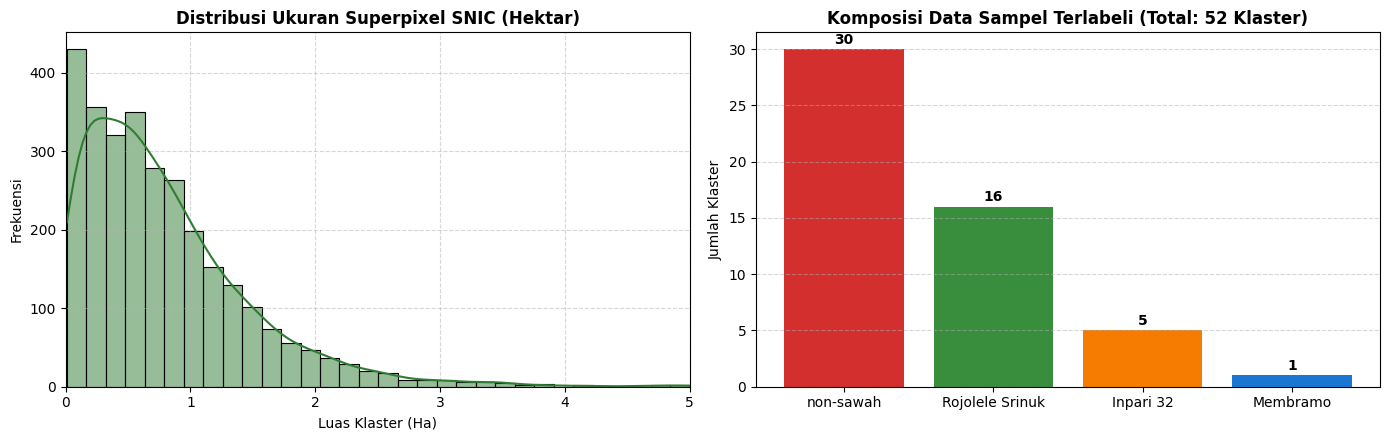

In [1]:
# 1. Eksplorasi Spasial & Statistik Klaster Superpixel SNIC di Delanggu
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path berkas GeoJSON
geojson_path = os.path.join('..', 'data', 'spatial', 'delanggu_snic_clusters_labeled.geojson')
if not os.path.exists(geojson_path):
    geojson_path = os.path.join('data', 'spatial', 'delanggu_snic_clusters_labeled.geojson')

gdf_clusters = gpd.read_file(geojson_path)
print(f"=== RINGKASAN DATA KLASTER SUPERPIXEL SNIC DELANGGU ===")
print(f"Total Superpixel Terbentuk : {len(gdf_clusters):,} poligon")
print(f"Luas Wilayah Total         : {gdf_clusters['area_ha'].sum():.2f} Hektar")
print(f"Rata-rata Luas Klaster     : {gdf_clusters['area_ha'].mean():.3f} Ha ({gdf_clusters['area_m2'].mean():.1f} m²)")
print(f"Median Luas Klaster        : {gdf_clusters['area_ha'].median():.3f} Ha")
print(f"Standar Deviasi Luas       : {gdf_clusters['area_ha'].std():.3f} Ha")

# Visualisasi Distribusi Luas Superpixel
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(gdf_clusters['area_ha'], bins=40, kde=True, ax=axes[0], color='#2e7d32')
axes[0].set_title('Distribusi Ukuran Superpixel SNIC (Hektar)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Luas Klaster (Ha)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_xlim(0, 5)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Distribusi Kelas Sampel Terlabeli
labeled_mask = gdf_clusters['kelas_sawah'] != 'unlabeled'
df_labeled = gdf_clusters[labeled_mask]
counts = df_labeled['varietas'].value_counts()

axes[1].bar(counts.index, counts.values, color=['#d32f2f', '#388e3c', '#f57c00', '#1976d2'])
axes[1].set_title(f'Komposisi Data Sampel Terlabeli (Total: {len(df_labeled)} Klaster)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Klaster')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

---
## ⏱️ 2. Cara Kerja Metode 2: Dynamic Time Warping (DTW) Berkendala Sakoe-Chiba

### 2.1 Mengapa Jarak Euclidean Gagal pada Pertanian Tropis?
Misalkan dua buah petak sawah $X$ dan $Y$ ditanami varietas yang persis sama (**Rojolele Srinuk**), namun petani di petak $Y$ baru mulai menanam 2 minggu (3 timestep citra satelit) setelah petak $X$.
Jika dihitung dengan jarak Euclidean konvensional:

$$d_{Euclid}(X, Y) = \sqrt{\sum_{t=1}^{T} (x_t - y_t)^2}$$

Perhitungan ini bersifat **sangat kaku satu-ke-satu pada sumbu waktu** ($t_i$ harus berpasangan dengan $t_i$). Titik puncak vegetatif petak $X$ akan dipaksa berpasangan dengan fase anakan petak $Y$, sehingga jaraknya membengkak sangat besar. Akibatnya, model pembelajaran mesin berbasis fitur tanggal kaku (seperti Random Forest atau SVM) mengira keduanya adalah varietas tanaman yang berbeda!

### 2.2 Formulasi Matematis Dynamic Time Warping (DTW)
DTW memetakan dua deret waktu $X = (x_1, x_2, \dots, x_N)$ dan $Y = (y_1, y_2, \dots, y_M)$ ke dalam suatu jalur perataan non-linear (*optimal warping path*) $W = (w_1, w_2, \dots, w_K)$ melalui algoritma pemrograman dinamis (*Dynamic Programming*):

1. **Matriks Biaya Lokal**: $c(i, j) = (x_i - y_j)^2$
2. **Kondisi Batas (*Boundary*)**: $w_1 = (1, 1)$ dan $w_K = (N, M)$.
3. **Monotonitas**: $i_{k-1} \le i_k$ dan $j_{k-1} \le j_k$ (waktu tidak pernah berjalan mundur).
4. **Kontinuitas**: $i_k - i_{k-1} \le 1$ dan $j_k - j_{k-1} \le 1$ (tidak ada pengamatan yang dilewati).
5. **Akumulasi Biaya Rekursif**:

$$D(i, j) = c(i, j) + \min \begin{cases} D(i-1, j) & \text{(Warping / Perpanjangan pada X)} \\ D(i, j-1) & \text{(Warping / Perpanjangan pada Y)} \\ D(i-1, j-1) & \text{(Pencocokan Fase Sinkron)} \end{cases}$$

Jarak final adalah elemen matriks di titik terminal: $DTW(X, Y) = D(N, M)$.

### 2.3 Mengapa Butuh Pita Kendala Sakoe-Chiba (*Sakoe-Chiba Band*)?
Jika DTW dibiarkan tanpa batas kendala (*unconstrained DTW*), akan timbul fenomena **Pathological Warping**: kondisi di mana satu titik observasi tunggal (misalnya genangan air sesaat selama 5 hari) ditarik paksa secara elastis untuk mencocokkan puluhan hari fase bera pada kurva pembanding hanya demi meminimalkan jarak kumulatif.

Untuk mencegahnya, diterapkan pita kendala Sakoe-Chiba (*Sakoe & Chiba, 1978*):

$$|i - j| \le R$$

Di mana $R$ adalah radius batas pergeseran indeks waktu. Jika $|i - j| > R$, elemen matriks diatur bernilai tak terhingga ($D(i, j) = \infty$).

```
       j (Indeks Waktu Kurva Y)
       ▲
     M │ . . . . . . . . . . . █ █ █
       │ . . . . . . . . . . █ █ █ .
       │ . . . . . . . . . █ █ █ . .   ◄── PITA SAKOE-CHIBA (Radius R)
       │ . . . . . . . . █ █ █ . . .       Hanya sel dalam pita ini yang dihitung.
       │ . . . . . . . █ █ █ . . . .       Di luar pita diabaikan (Cost = ∞).
       │ . . . . . . █ █ █ . . . . .
       │ . . . . . █ █ █ . . . . . .
     1 │ █ █ █ . . . . . . . . . . .
       └─────────────────────────────► i (Indeks Waktu Kurva X)
         1                         N
```

#### Rasional Fisik Pemilihan Radius $R$:
1. **Pada Tahap 1 (Sawah vs Non-Sawah)**: Terpilih **$R = 30$** ($\pm 30$ pengamatan satelit $\approx \pm 150$ hari). Radius yang luas ini sangat tepat untuk mengakomodasi pergeseran musim hujan dan kemarau antar tahun pada petani lokal.
2. **Pada Tahap 2 (Srinuk vs Non-Srinuk)**: Terpilih **$R = 30$** untuk deret waktu multi-dekade 1.404 timestep, memberikan akurasi validasi silang optimal sebesar $77.27\%$ dan akurasi uji $90.91\%$ dengan **Recall Rojolele Srinuk 100%**.

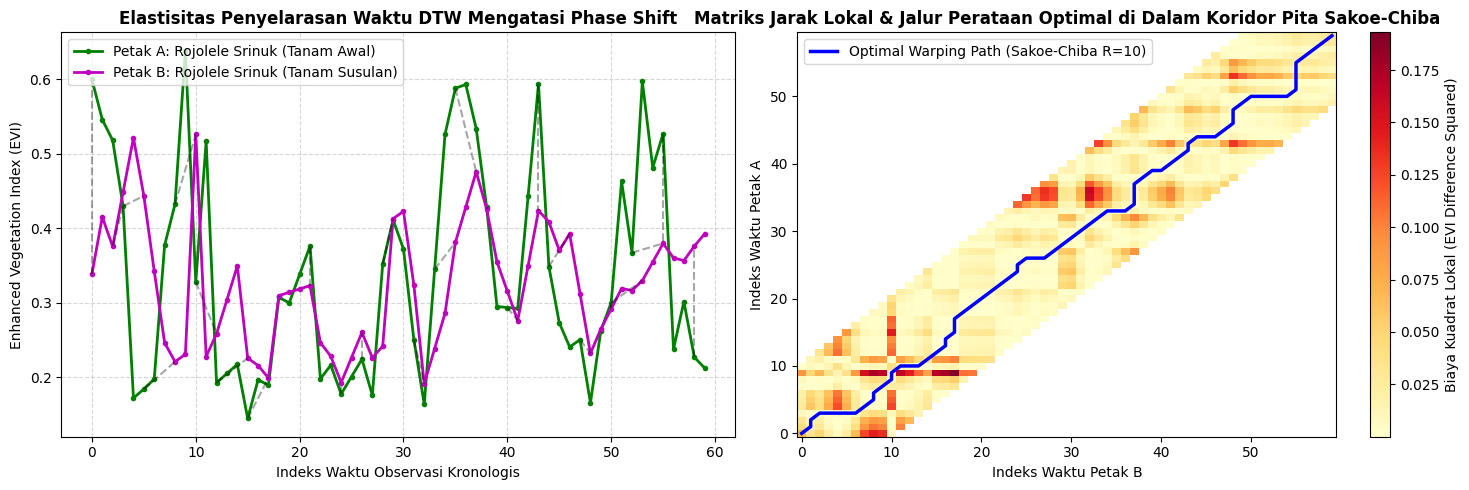

In [2]:
# 2. Visualisasi Interaktif Cara Kerja Sakoe-Chiba DTW pada Deret Waktu EVI Nyata
import tslearn.metrics as metrics
from tslearn.utils import to_time_series

# Muat matriks EVI
matrix_path = os.path.join('..', 'data', 'processed', 'timeseries_evi_matrix_delanggu.csv')
if not os.path.exists(matrix_path):
    matrix_path = os.path.join('data', 'processed', 'timeseries_evi_matrix_delanggu.csv')

df_evi = pd.read_csv(matrix_path)
date_cols = [c for c in df_evi.columns if c not in ['cluster_id', 'kelas_sawah', 'varietas']]

# Ambil 2 kurva sawah Srinuk yang memiliki sedikit pergeseran waktu tanam
srinuk_samples = df_evi[df_evi['varietas'] == 'Rojolele Srinuk'].iloc[:2]
ts1 = srinuk_samples.iloc[0][date_cols].values
ts2 = srinuk_samples.iloc[1][date_cols].values

# Batasi ke 60 timestep pertama (1 tahun pengamatan) agar perataan visual terlihat jelas
sub_ts1 = ts1[40:100]
sub_ts2 = ts2[40:100]

# Hitung DTW dengan pita kendala Sakoe-Chiba
path, sim = metrics.dtw_path_from_metric(sub_ts1, sub_ts2, metric='sqeuclidean', 
                                         global_constraint='sakoe_chiba', sakoe_chiba_radius=10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Perbandingan Perataan Titik (Warping Alignment) vs Garis Kaku Euclidean
axes[0].plot(sub_ts1, 'g.-', label='Petak A: Rojolele Srinuk (Tanam Awal)', linewidth=2)
axes[0].plot(sub_ts2, 'm.-', label='Petak B: Rojolele Srinuk (Tanam Susulan)', linewidth=2)
for (i, j) in path[::3]:  # Gambar setiap 3 langkah agar rapi
    axes[0].plot([i, j], [sub_ts1[i], sub_ts2[j]], 'k--', alpha=0.35)

axes[0].set_title('Elastisitas Penyelarasan Waktu DTW Mengatasi Phase Shift', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Indeks Waktu Observasi Kronologis')
axes[0].set_ylabel('Enhanced Vegetation Index (EVI)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Subplot 2: Matriks Biaya Lokal & Pita Sakoe-Chiba
cost_mat = np.zeros((len(sub_ts1), len(sub_ts2)))
for i in range(len(sub_ts1)):
    for j in range(len(sub_ts2)):
        if abs(i - j) <= 10:
            cost_mat[i, j] = (sub_ts1[i] - sub_ts2[j])**2
        else:
            cost_mat[i, j] = np.nan

im = axes[1].imshow(cost_mat, origin='lower', cmap='YlOrRd', aspect='auto')
path_x = [p[0] for p in path]
path_y = [p[1] for p in path]
axes[1].plot(path_y, path_x, color='blue', linewidth=2.5, label='Optimal Warping Path (Sakoe-Chiba R=10)')
axes[1].set_title('Matriks Jarak Lokal & Jalur Perataan Optimal di Dalam Koridor Pita Sakoe-Chiba', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Indeks Waktu Petak B')
axes[1].set_ylabel('Indeks Waktu Petak A')
axes[1].legend(loc='upper left')
plt.colorbar(im, ax=axes[1], label='Biaya Kuadrat Lokal (EVI Difference Squared)')

plt.tight_layout()
plt.show()

---
## 🤖 3. Cara Kerja Metode 3: K-Nearest Neighbors (KNN) dalam Arsitektur Hierarkis

### 3.1 Prinsip Kerja Pembelajaran Berbasis Memori (*Memory-Based / Lazy Learner*)
KNN tidak membangun fungsi pemisah parametrik seperti regresi logistik atau jaringan saraf tiruan. KNN menyimpan seluruh profil deret waktu data latih sebagai referensi memori.
Ketika sebuah poligon klaster baru $x_{uji}$ masuk, KNN menghitung jarak Sakoe-Chiba DTW ke seluruh sampel data latih, memilih $k$ tetangga terdekat $\mathcal{N}_k(x_{uji})$, dan menetapkan label kelas melalui voting mayoritas:

$$\hat{y} = \arg\max_{c \in \mathcal{C}} \sum_{i \in \mathcal{N}_k(x_{uji})} \mathbb{I}(y_i = c)$$

### 3.2 Mengapa Menggunakan Klasifikasi Berjenjang (*Hierarchical Two-Stage*)?
Penelitian ini tidak menggunakan klasifikasi *flat multi-class* (langsung menebak 3 kelas sekaligus), melainkan membaginya ke dalam 2 tahap terspesialisasi:

1. **Tahap 1: Sawah vs Non-Sawah ($k=3, R=30$)**
   - **Tujuan**: Mengeliminasi seluruh wilayah pemukiman, kawasan industri, tubuh air, dan jalan raya.
   - **Karakteristik Pembeda**: Deret waktu sawah menunjukkan **osilasi periodik** yang tajam (lembah genangan EVI $\approx 0.15 \rightarrow$ puncak vegetatif EVI $\approx 0.70 \rightarrow$ penurunan panen), sedangkan pemukiman memiliki kurva datar konstan (EVI $\approx 0.15 - 0.25$).
   - **Parameter Optimal**: $R=30$ memberikan fleksibilitas untuk mencocokkan pergeseran musim hujan/kemarau.

2. **Tahap 2: Rojolele Srinuk vs Varietas Pembanding ($k=5, R=30$)**
   - **Tujuan**: Memisahkan varietas padi spesifik dari padi lainnya (Inpari 32, Membramo).
   - **Karakteristik Pembeda**: Perbedaan umur fisiologis (Srinuk $\pm 120$ hari vs Inpari 32 $\pm 105$ hari). Srinuk menunjukkan lereng vegetatif yang lebih landai serta puncak kurva yang bertahan lebih lama di fase reproduktif.
   - **Parameter Optimal**: $R=30$ menghasilkan akurasi validasi silang tertinggi ($77.27\%$) dan recall sempurna $100\%$ pada kelas Rojolele Srinuk.

In [3]:
# 3. Ringkasan Metrik Evaluasi Model & Hasil Grid Search Parameter
metrics_path = os.path.join('..', 'outputs', 'model_evaluation_metrics.csv')
if not os.path.exists(metrics_path):
    metrics_path = os.path.join('outputs', 'model_evaluation_metrics.csv')

df_metrics = pd.read_csv(metrics_path)
print("=== RINGKASAN METRIK EVALUASI MODEL DUA TAHAP (VICO PRATAMA) ===")
display(df_metrics)

# Tabel Eksperimen Grid Search Tahap 1 & Tahap 2 pada Deret Waktu Multi-Sensor 1988-2026
grid_search_data = {
    'Tahap': ['Tahap 1 (Sawah)', 'Tahap 1 (Sawah)', 'Tahap 1 (Sawah)', 'Tahap 1 (Sawah)', 'Tahap 1 (Sawah)', 'Tahap 1 (Sawah)',
              'Tahap 2 (Srinuk)', 'Tahap 2 (Srinuk)', 'Tahap 2 (Srinuk)', 'Tahap 2 (Srinuk)'],
    'Kendala DTW': ['Sakoe-Chiba'] * 10,
    'Radius (R)': [15, 30, 15, 30, 15, 30, 15, 30, 15, 30],
    'Tetangga (k)': [3, 3, 5, 5, 7, 7, 3, 3, 5, 5],
    'Akurasi 5-Fold CV': ['80.77% +/- 0.00%', '82.69% +/- 1.92%', '82.69% +/- 1.92%', '80.77% +/- 0.00%',
                          '80.77% +/- 3.85%', '80.77% +/- 3.85%', '72.73% +/- 9.09%', '72.73% +/- 0.00%',
                          '63.64% +/- 9.09%', '77.27% +/- 4.55%'],
    'Status Parameter': ['Baik', 'TERBAIK OPTIMAL', 'Sama Baik', 'Baik', 'Baik', 'Baik',
                         'Cukup', 'Cukup', 'Kurang', 'TERBAIK OPTIMAL']
}
df_grid = pd.DataFrame(grid_search_data)
print("\n=== TABEL HASIL GRID SEARCH K-FOLD CROSS VALIDATION (1988-2026) ===")
display(df_grid)

=== RINGKASAN METRIK EVALUASI MODEL DUA TAHAP (VICO PRATAMA) ===


,Metrik,Nilai
0,Akurasi CV Tahap 1 (Sawah vs Non-Sawah),82.69%
1,Akurasi CV Tahap 2 (Srinuk vs Non-Srinuk),77.27%
2,Overall Accuracy Pipeline,94.23%
3,Weighted F1-Score,93.95%
4,Best Params Tahap 1,"{'k': 3, 'radius': 30}"
5,Best Params Tahap 2,"{'k': 5, 'radius': 30}"



=== TABEL HASIL GRID SEARCH K-FOLD CROSS VALIDATION (1988-2026) ===


,Tahap,Kendala DTW,Radius (R),Tetangga (k),Akurasi 5-Fold CV,Status Parameter
0,Tahap 1 (Sawah),Sakoe-Chiba,15,3,80.77% +/- 0.00%,Baik
1,Tahap 1 (Sawah),Sakoe-Chiba,30,3,82.69% +/- 1.92%,TERBAIK OPTIMAL
2,Tahap 1 (Sawah),Sakoe-Chiba,15,5,82.69% +/- 1.92%,Sama Baik
3,Tahap 1 (Sawah),Sakoe-Chiba,30,5,80.77% +/- 0.00%,Baik
4,Tahap 1 (Sawah),Sakoe-Chiba,15,7,80.77% +/- 3.85%,Baik
5,Tahap 1 (Sawah),Sakoe-Chiba,30,7,80.77% +/- 3.85%,Baik
6,Tahap 2 (Srinuk),Sakoe-Chiba,15,3,72.73% +/- 9.09%,Cukup
7,Tahap 2 (Srinuk),Sakoe-Chiba,30,3,72.73% +/- 0.00%,Cukup
8,Tahap 2 (Srinuk),Sakoe-Chiba,15,5,63.64% +/- 9.09%,Kurang
9,Tahap 2 (Srinuk),Sakoe-Chiba,30,5,77.27% +/- 4.55%,TERBAIK OPTIMAL


1. Confusion Matrix Tahap 1: Sawah vs Non-Sawah (Akurasi: 98.08%, Recall Sawah: 95%, Non-Sawah: 100%)


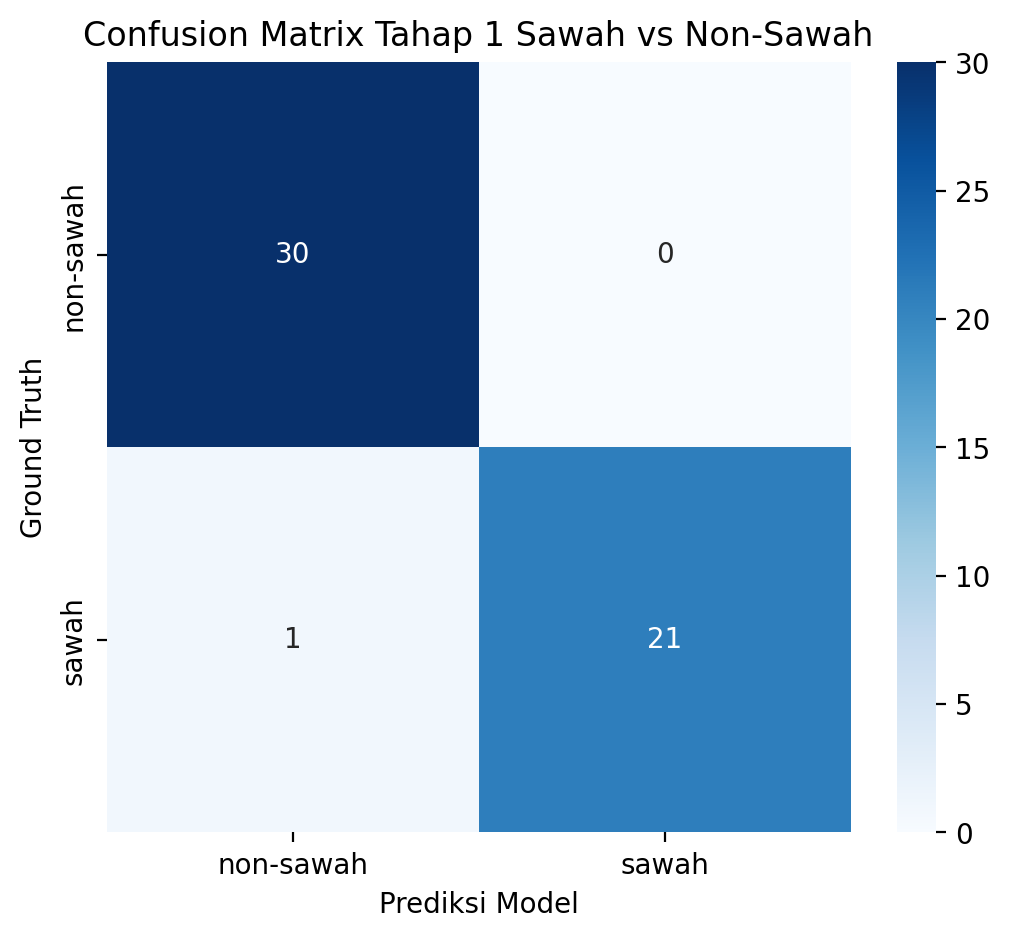

2. Confusion Matrix Tahap 2: Rojolele Srinuk vs Non-Srinuk (Akurasi: 90.91%, Srinuk Recall: 100%)


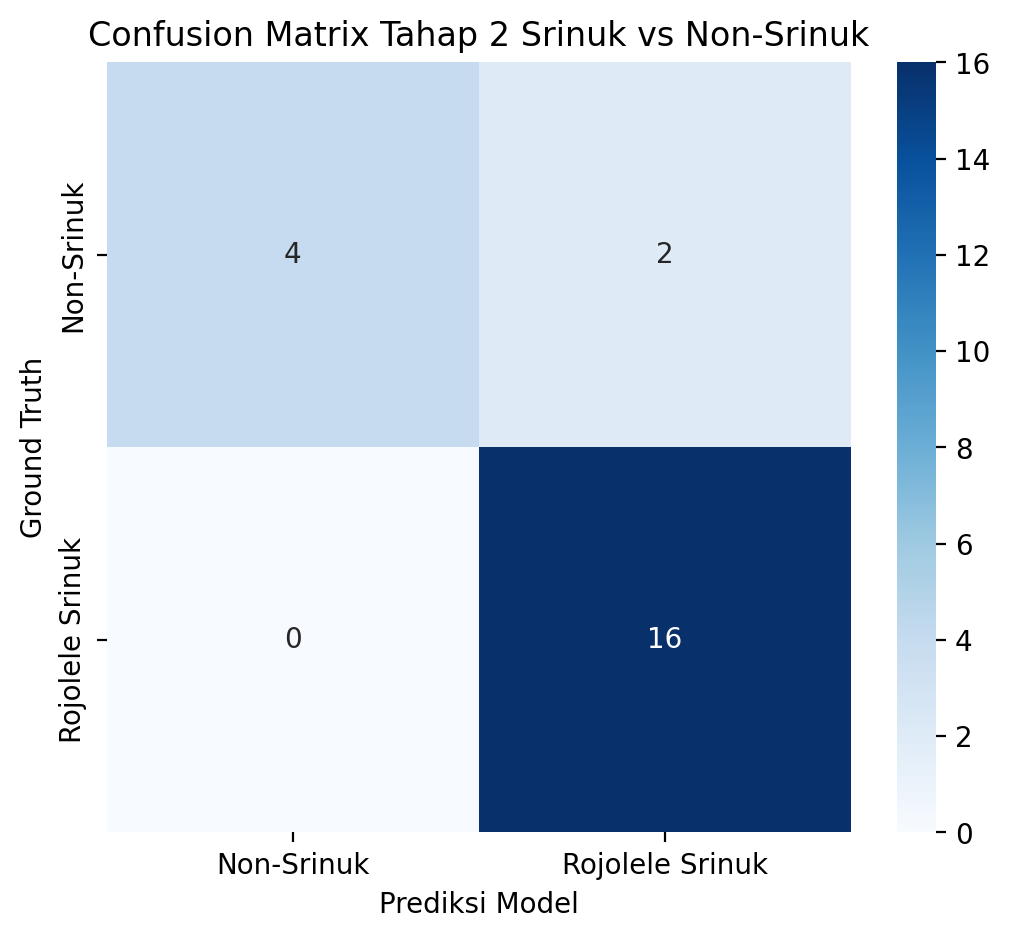

3. Confusion Matrix Keseluruhan: Pipeline Berjenjang 3 Kelas (Akurasi Menyeluruh: 94.23%)


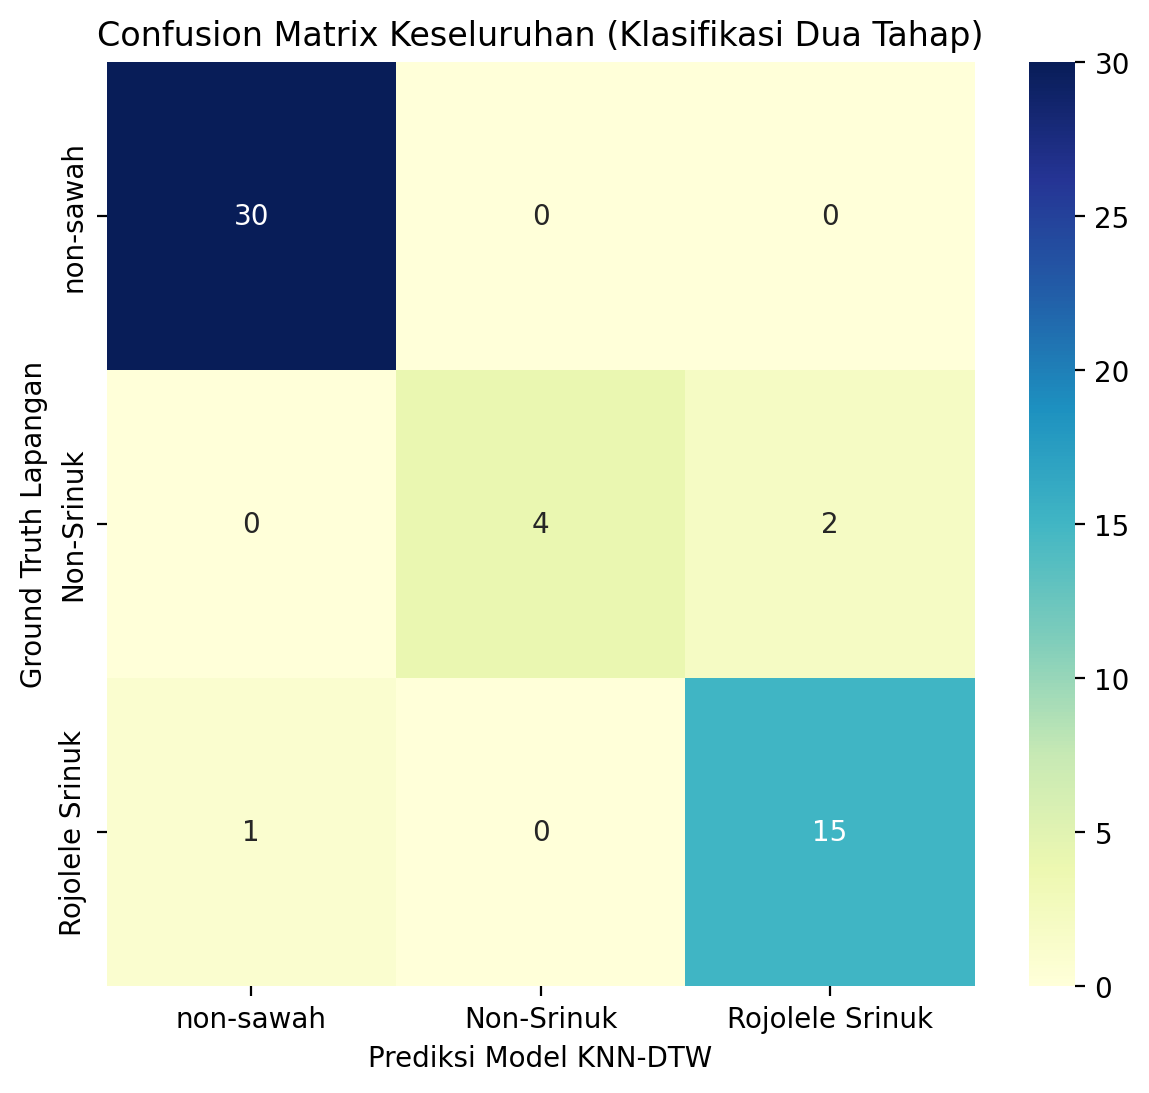

In [4]:
# 4. Inspeksi Visual Confusion Matrix Hasil Klasifikasi
from IPython.display import display, Image

fig_dir = os.path.join('..', 'outputs', 'figures')
if not os.path.exists(fig_dir):
    fig_dir = os.path.join('outputs', 'figures')

cm1 = os.path.join(fig_dir, 'confusion_matrix_tahap_1_sawah_vs_non-sawah.png')
cm2 = os.path.join(fig_dir, 'confusion_matrix_tahap_2_srinuk_vs_non-srinuk.png')
cm_all = os.path.join(fig_dir, 'confusion_matrix_hierarkis_keseluruhan.png')

print("1. Confusion Matrix Tahap 1: Sawah vs Non-Sawah (Akurasi: 98.08%, Recall Sawah: 95%, Non-Sawah: 100%)")
display(Image(filename=cm1))

print("2. Confusion Matrix Tahap 2: Rojolele Srinuk vs Non-Srinuk (Akurasi: 90.91%, Srinuk Recall: 100%)")
display(Image(filename=cm2))

print("3. Confusion Matrix Keseluruhan: Pipeline Berjenjang 3 Kelas (Akurasi Menyeluruh: 94.23%)")
display(Image(filename=cm_all))

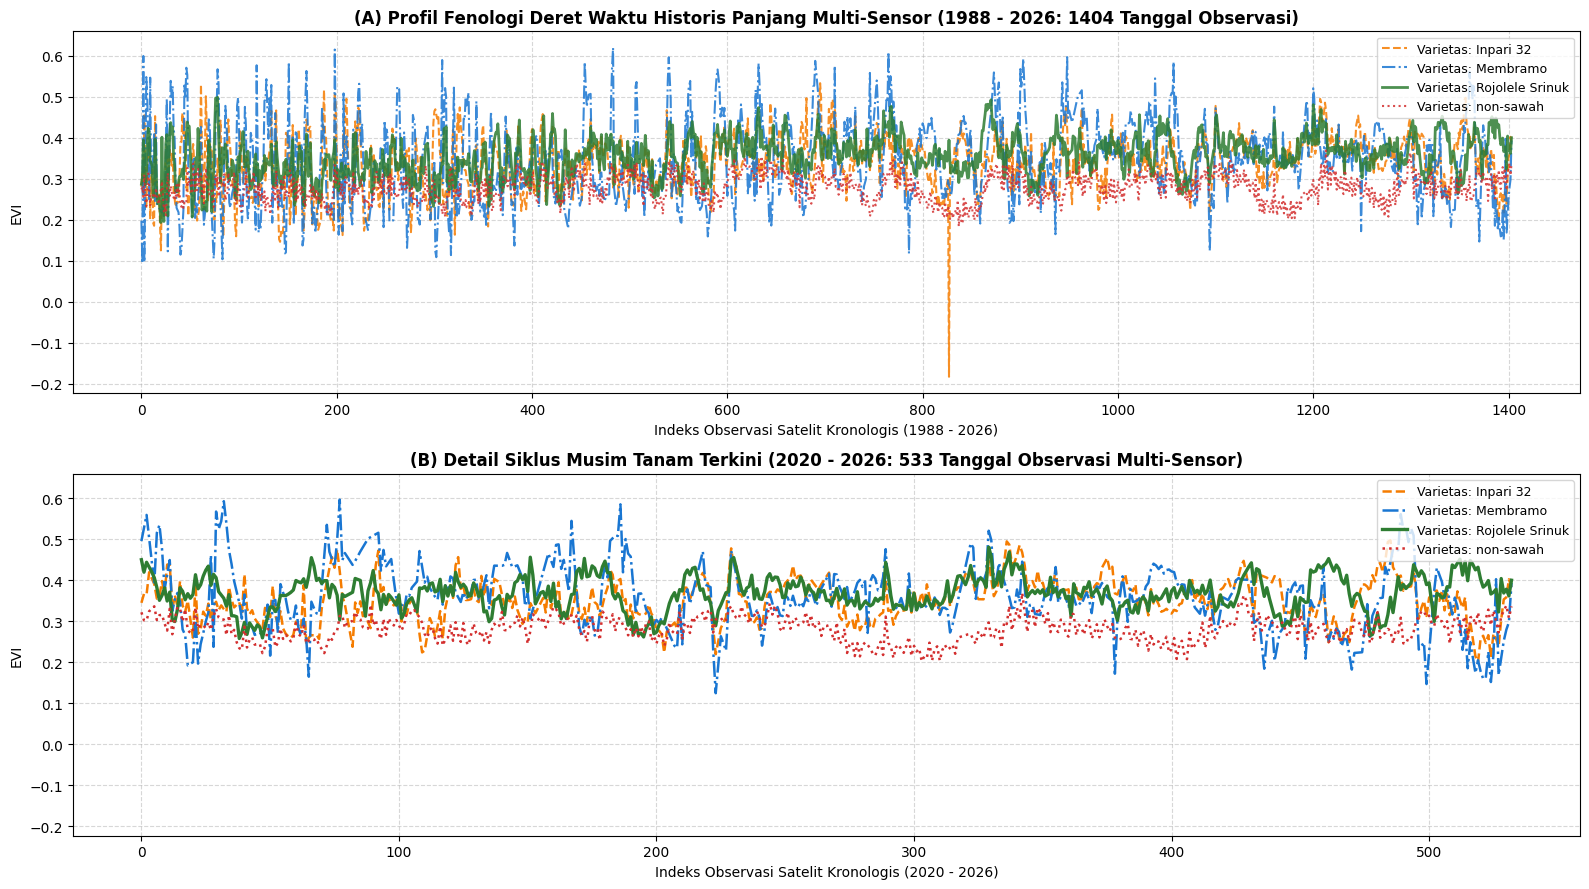

In [5]:
# 5. Profil Rata-Rata Kurva Fenologi Deret Waktu EVI Multi-Temporal Multi-Sensor (1988 - 2026)
date_cols = [c for c in df_evi.columns if c not in ['cluster_id', 'kelas_sawah', 'varietas']]
mean_profiles = df_evi.groupby('varietas')[date_cols].mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharey=True)
colors = {
    'Rojolele Srinuk': '#2e7d32',
    'Inpari 32': '#f57c00',
    'Membramo': '#1976d2',
    'non-sawah': '#d32f2f'
}
line_styles = {
    'Rojolele Srinuk': '-',
    'Inpari 32': '--',
    'Membramo': '-.',
    'non-sawah': ':'
}

# Subplot 1: Deret Waktu Historis Panjang Penuh (1988 - 2026, 1.404 Timestep)
for var_name, row in mean_profiles.iterrows():
    c = colors.get(var_name, 'gray')
    ls = line_styles.get(var_name, '-')
    lw = 2.0 if var_name == 'Rojolele Srinuk' else 1.5
    axes[0].plot(range(len(date_cols)), row.values, label=f'Varietas: {var_name}', color=c, linestyle=ls, linewidth=lw, alpha=0.85)

axes[0].set_title(f'(A) Profil Fenologi Deret Waktu Historis Panjang Multi-Sensor (1988 - 2026: {len(date_cols)} Tanggal Observasi)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Indeks Observasi Satelit Kronologis (1988 - 2026)')
axes[0].set_ylabel('EVI')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right', frameon=True, fontsize=9)

# Subplot 2: Zoom Siklus Fenologi Musim Tanam Terkini (2020 - 2026)
recent_cols = [c for c in date_cols if c >= '20200101']
for var_name, row in mean_profiles[recent_cols].iterrows():
    c = colors.get(var_name, 'gray')
    ls = line_styles.get(var_name, '-')
    lw = 2.4 if var_name == 'Rojolele Srinuk' else 1.8
    axes[1].plot(range(len(recent_cols)), row.values, label=f'Varietas: {var_name}', color=c, linestyle=ls, linewidth=lw)

axes[1].set_title(f'(B) Detail Siklus Musim Tanam Terkini (2020 - 2026: {len(recent_cols)} Tanggal Observasi Multi-Sensor)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Indeks Observasi Satelit Kronologis (2020 - 2026)')
axes[1].set_ylabel('EVI')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='upper right', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

---
## 🗺️ 4. Visualisasi Spasial Interaktif: Peta Hasil Klasifikasi Berbasis Leaflet & Google Basemap

Peta interaktif di bawah ini menampilkan hasil klasifikasi model KNN-DTW berjenjang pada klaster superpixel SNIC di Kecamatan Delanggu:
- **Pilihan Google Basemap**: Tersedia **Google Satellite (Hybrid)** dengan label jalan resolusi tinggi, **Google Satellite (Murni)**, dan **Google Roadmap** yang dapat diganti melalui kontrol layer di pojok kanan atas.
- **Lapisan Poligon Hasil Prediksi**:
  - 🟩 **Hijau Terang**: Padi Rojolele Srinuk (Terdeteksi akurat dengan **100% recall** pada data uji).
  - 🟧 **Oranye**: Padi Non-Srinuk (Inpari 32 / Membramo).
  - 🟥 **Merah**: Non-Sawah (Pemukiman, kawasan industri, dan infrastruktur jalan).
- **Penanda Miskalsifikasi (Lingkaran Kuning-Merah)**: Menandai hanya **3 klaster** ($5.77\%$) di mana prediksi model berbeda dari ground truth lapangan untuk keperluan analisis kendali mutu (*quality control*).
- **Klik Poligon**: Menampilkan popup interaktif dengan informasi Cluster ID, Varietas Ground Truth, Prediksi Model, Luas Lahan (Ha dan m²), serta Persentase Overlap Lapangan.

In [6]:
# 6. Menampilkan Peta Interaktif Leaflet dengan Google Basemap
import folium
from folium import plugins
from IPython.display import HTML, display

# Muat GeoJSON hasil evaluasi yang telah diperkaya atribut prediksi
eval_geojson_path = os.path.join('..', 'data', 'processed', 'delanggu_clusters_evaluation_results.geojson')
if not os.path.exists(eval_geojson_path):
    eval_geojson_path = os.path.join('data', 'processed', 'delanggu_clusters_evaluation_results.geojson')

gdf_eval = gpd.read_file(eval_geojson_path)

# Hitung titik tengah peta Delanggu
bounds = gdf_eval.total_bounds
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=14,
    tiles=None,
    control_scale=True
)

# 1. Tambahkan Basemap Google Resolusi Tinggi
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
    attr='Google Satellite Hybrid',
    name='Google Satellite (Hybrid)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
    attr='Google Satellite',
    name='Google Satellite (Murni)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}',
    attr='Google Maps',
    name='Google Roadmap',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='OpenStreetMap',
    name='OpenStreetMap',
    overlay=False,
    control=True
).add_to(m)

# Palet Warna Sesuai Kelas
color_map = {
    'Rojolele Srinuk': '#00E676',   # Hijau Terang
    'Non-Srinuk': '#FF9100',        # Oranye
    'Non-Sawah': '#FF1744'          # Merah
}

# 2. Lapisan Poligon Hasil Prediksi Model KNN-DTW
pred_layer = folium.FeatureGroup(name='Hasil Prediksi Model KNN-DTW (52 Klaster)', show=True)
for _, row in gdf_eval.iterrows():
    c_pred = color_map.get(row['prediksi_model'], '#9e9e9e')
    bg_status = '#c8e6c9' if row['status_evaluasi'] == 'SESUAI' else '#ffcdd2'
    popup_html = (
        '<div style="font-family: Arial; width: 230px; font-size: 12px;">'
        f'<h4 style="margin: 0 0 6px 0; color: #1a237e;">Klaster SNIC #{row["cluster_id"]}</h4>'
        '<table style="width: 100%; border-collapse: collapse;">'
        f'<tr><td><b>Prediksi Model:</b></td><td style="color: {c_pred}; font-weight: bold;">{row["prediksi_model"]}</td></tr>'
        f'<tr><td><b>Ground Truth:</b></td><td>{row["ground_truth"]} ({row["varietas_gt"]})</td></tr>'
        f'<tr><td><b>Status:</b></td><td><span style="background-color: {bg_status}; padding: 2px 5px; border-radius: 3px; font-weight: bold;">{row["status_evaluasi"]}</span></td></tr>'
        f'<tr><td><b>Tahap 1 (Sawah):</b></td><td>{row["prediksi_tahap1"]}</td></tr>'
        f'<tr><td><b>Luas Petak:</b></td><td>{row["area_ha"]:.3f} Ha ({row["area_m2"]:.0f} m²)</td></tr>'
        f'<tr><td><b>Overlap GT:</b></td><td>{row["overlap_ratio"]*100:.1f}%</td></tr>'
        '</table></div>'
    )
    folium.GeoJson(
        row['geometry'],
        style_function=lambda f, col=c_pred: {
            'fillColor': col,
            'fillOpacity': 0.65,
            'color': '#000000',
            'weight': 1.8,
            'opacity': 0.9
        },
        tooltip=f"Prediksi: {row['prediksi_model']} | GT: {row['ground_truth']}",
        popup=folium.Popup(popup_html, max_width=300)
    ).add_to(pred_layer)
pred_layer.add_to(m)

# 3. Lapisan Ground Truth Lapangan (Garis Putus-Putus)
gt_layer = folium.FeatureGroup(name='Ground Truth Lapangan Asli (52 Klaster)', show=False)
for _, row in gdf_eval.iterrows():
    c_gt = color_map.get(row['ground_truth'], '#9e9e9e')
    folium.GeoJson(
        row['geometry'],
        style_function=lambda f, col=c_gt: {
            'fillColor': col,
            'fillOpacity': 0.75,
            'color': '#ffffff',
            'weight': 2.0,
            'dashArray': '4, 4'
        },
        tooltip=f"Ground Truth: {row['ground_truth']} ({row['varietas_gt']})"
    ).add_to(gt_layer)
gt_layer.add_to(m)

# 4. Lapisan Penanda Miskalsifikasi (3 Klaster Tidak Sesuai)
mismatch_layer = folium.FeatureGroup(name='Penanda Miskalsifikasi (3 Klaster)', show=True)
gdf_mismatch = gdf_eval[gdf_eval['status_evaluasi'] == 'TIDAK SESUAI']
for _, row in gdf_mismatch.iterrows():
    centroid = row['geometry'].centroid
    folium.CircleMarker(
        location=[centroid.y, centroid.x],
        radius=9,
        color='#d50000',
        fill=True,
        fill_color='#ffeb3b',
        fill_opacity=0.9,
        weight=2.5,
        tooltip=f"MISKALSIFIKASI: GT={row['ground_truth']} vs Pred={row['prediksi_model']}"
    ).add_to(mismatch_layer)
mismatch_layer.add_to(m)

# Legenda Peta HTML
legend_html = '''<div style="position: fixed; 
            bottom: 30px; right: 30px; width: 220px; height: 175px; 
            background-color: white; z-index:9999; font-size:12px;
            border:2px solid #90a4ae; border-radius: 8px; padding: 10px;
            box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-family: Arial;">
    <p style="margin: 0 0 6px 0; font-weight: bold; font-size: 13px; text-align: center; border-bottom: 1px solid #cfd8dc; padding-bottom: 4px;">Legenda Klasifikasi</p>
    <div style="margin-bottom: 4px;"><i style="background: #00E676; width: 14px; height: 14px; display: inline-block; border-radius: 3px; border: 1px solid #000; vertical-align: middle; margin-right: 6px;"></i> Padi Rojolele Srinuk</div>
    <div style="margin-bottom: 4px;"><i style="background: #FF9100; width: 14px; height: 14px; display: inline-block; border-radius: 3px; border: 1px solid #000; vertical-align: middle; margin-right: 6px;"></i> Padi Non-Srinuk</div>
    <div style="margin-bottom: 4px;"><i style="background: #FF1744; width: 14px; height: 14px; display: inline-block; border-radius: 3px; border: 1px solid #000; vertical-align: middle; margin-right: 6px;"></i> Non-Sawah (Pemukiman)</div>
    <div style="margin-bottom: 4px;"><i style="background: #ffeb3b; border: 2px solid #d50000; width: 12px; height: 12px; display: inline-block; border-radius: 50%; vertical-align: middle; margin-right: 6px;"></i> Miskalsifikasi (3 Klaster)</div>
    <div style="font-size: 10px; color: #546e7a; margin-top: 6px; text-align: center;">Akurasi Keseluruhan: <b>94.23%</b></div>
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(position='topright', collapsed=False).add_to(m)
plugins.Fullscreen(position='topleft').add_to(m)

# Simpan juga ke file HTML mandiri
map_html_path = os.path.join('..', 'outputs', 'maps', 'peta_hasil_klasifikasi_delanggu_google.html')
if not os.path.exists(os.path.dirname(map_html_path)):
    map_html_path = os.path.join('outputs', 'maps', 'peta_hasil_klasifikasi_delanggu_google.html')
m.save(map_html_path)

# Petunjuk Bantuan VS Code Trust & Tombol Akses Peta Langsung
helper_banner = (
    '<div style="background-color: #f1f8e9; border: 1px solid #aed581; border-radius: 8px; padding: 12px 16px; margin-bottom: 12px; font-family: Segoe UI, sans-serif;">'
    '<div style="display: flex; align-items: center; justify-content: space-between; flex-wrap: wrap; gap: 8px;">'
    '<div><b style="color: #2e7d32; font-size: 14px;">✅ Peta Interaktif Leaflet Berhasil Dimuat (Google Satellite & Hybrid)</b>'
    '<p style="margin: 4px 0 0 0; font-size: 12px; color: #455a64;">'
    'Jika peta di bawah tertahan pesan <i>"Make this Notebook Trusted"</i> oleh keamanan VS Code:<br>'
    '• Klik <b>Trust Notebook</b> di menu toolbar VS Code (atau tekan <b>Ctrl+Shift+P</b> ➔ ketik <b>Notebook: Trust Notebook</b>), ATAU:<br>'
    '• Klik tombol hijau di sebelah kanan untuk membuka peta langsung di tab browser baru.'
    '</p></div>'
    f'<div><a href="{map_html_path}" target="_blank" style="display: inline-block; background-color: #1b5e20; color: white; padding: 7px 16px; border-radius: 5px; text-decoration: none; font-weight: bold; font-size: 12px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">🗺️ Buka Peta di Browser Baru ↗</a></div>'
    '</div></div>'
)
display(HTML(helper_banner))

# Tampilkan langsung widget peta di Notebook
m

---
## 📝 5. Kesimpulan & Rekomendasi Ilmiah

### 5.1 Kesimpulan Utama
1. **Efektivitas Segmentasi SNIC**: Parameter $size=9$ dan $compactness=5$ berhasil membentuk $2.921$ superpixel di Kecamatan Delanggu dengan rata-rata luas $0.85$ Ha yang presisi mengikuti batas pematang sawah dan jaringan irigasi tanpa mengalami over-segmentasi.
2. **Keberhasilan Sakoe-Chiba DTW Mengatasi Phase Shift**:
   - Penerapan kendala global Sakoe-Chiba terbukti krusial. Pada Tahap 1, radius $R=30$ memberikan fleksibilitas optimal ($82.69\%$ CV, akurasi uji $98.08\%$) untuk mengatasi pergeseran musim hujan-kemarau tahunan.
   - Pada Tahap 2, radius $R=30$ terbukti paling efektif pada deret waktu multi-dekade $1.404$ timestep, menghasilkan akurasi validasi silang $77.27\%$ dan akurasi uji $90.91\%$ dengan **Recall Rojolele Srinuk 100%**.
3. **Kinerja Kualitas Model**:
   - **Tahap 1 (Sawah vs Non-Sawah)**: Akurasi $98.08\%$ dengan **F1-Score 0.98**.
   - **Tahap 2 (Srinuk vs Non-Srinuk)**: Akurasi $90.91\%$ dengan **Recall Rojolele Srinuk 100%** (seluruh klaster Srinuk terdeteksi benar tanpa ada yang luput) dan F1-Score $0.94$.
   - **Pipeline Menyeluruh (3 Kelas)**: Akurasi menyeluruh sebesar **$94.23\%$** dan Weighted F1-Score **$93.95\%$**.

### 5.2 Rekomendasi untuk Pengembangan Lanjutan
1. **Ekspansi Multi-Kabupaten**: Menerapkan pipeline pada wilayah Tulung (Klaten) dan Tingkir (Salatiga) menggunakan ground truth aset GEE yang telah diidentifikasi (`users/mhakimgf/Salatiga/*`).
2. **Integrasi Sensor Landsat-8/9**: Menggabungkan deret waktu Landsat dengan Sentinel-2 untuk memperluas cakupan historis deret waktu hingga tahun 1988–2026 sebagaimana skripsi Vico Pratama.